In [39]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.utils import resample
from sklearn.calibration import CalibratedClassifierCV



# A simple approach to estimating churn

Ideas:

- Do some simple data exploratory data analysis to get an understanding of the data 
    - Check for NAs - done
    - Correlation checks for the continous variables - done
    - Vis some of the data -the 2 continous variables coloured with the Churn variable - done
- Create a validation set 
- Create three intial models and see how well they perform on the test set


## Exploratory data Analysis

Just to get some ideas about the data.

In [ ]:
data = pd.read_csv("train.csv")
data.info()
print(len(data["id"].unique())/len(data.index))
data = data.drop("id", axis=1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [22]:
data[data.isnull().any(axis=1)] # No NAs in all the data
data['Churn'].value_counts()

Churn
No     460377
Yes    133817
Name: count, dtype: int64

In [24]:
for i in data.select_dtypes("object").columns:
    print(i)
    print(data[i].unique())

gender
['Male' 'Female']
Partner
['Yes' 'No']
Dependents
['Yes' 'No']
PhoneService
['Yes' 'No']
MultipleLines
['No' 'Yes' 'No phone service']
InternetService
['DSL' 'Fiber optic' 'No']
OnlineSecurity
['Yes' 'No' 'No internet service']
OnlineBackup
['No' 'Yes' 'No internet service']
DeviceProtection
['Yes' 'No' 'No internet service']
TechSupport
['Yes' 'No' 'No internet service']
StreamingTV
['No' 'Yes' 'No internet service']
StreamingMovies
['No' 'Yes' 'No internet service']
Contract
['One year' 'Two year' 'Month-to-month']
PaperlessBilling
['Yes' 'No']
PaymentMethod
['Mailed check' 'Credit card (automatic)' 'Electronic check'
 'Bank transfer (automatic)']
Churn
['No' 'Yes']


Somehow there seems to be a relationships in the variables with each other. Potentially its worht combining them.

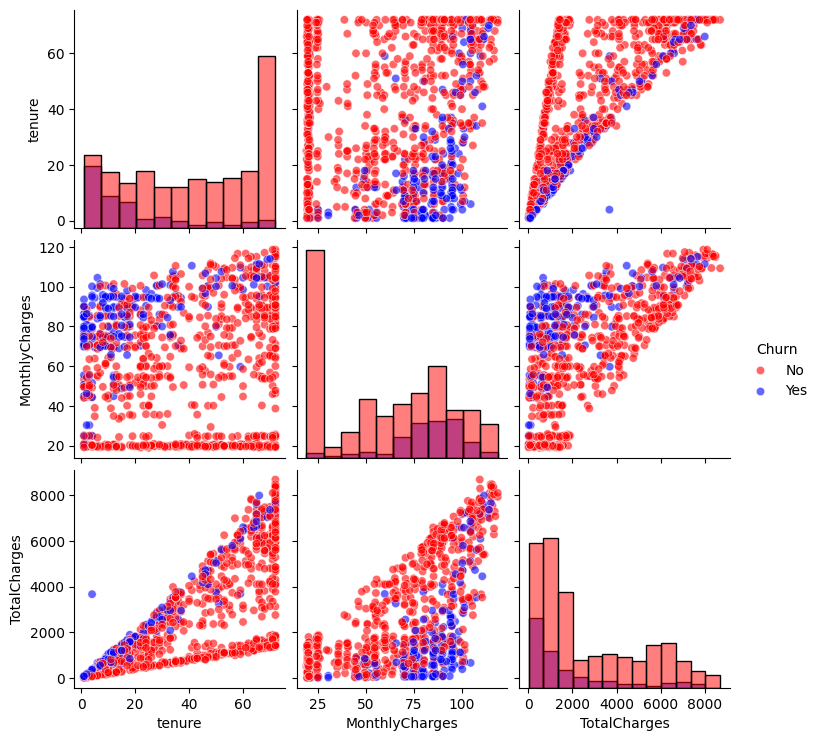

In [25]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
sns.pairplot(data[numeric_cols + ['Churn']].sample(1000, random_state=42), 
            hue='Churn', 
            palette={"No": 'red', "Yes": 'blue'}, 
            diag_kind='hist',
            plot_kws={'alpha':0.6})

# Train Test Split and Modelling

In [30]:

# ================================
# TRAIN / TEST SPLIT
# ================================
train_df, test_df = train_test_split(data, test_size=0.2, random_state=42)

# Split features + target
X = train_df.drop("Churn", axis=1)
y = train_df["Churn"]

X_test = test_df.drop("Churn", axis=1)
y_test = test_df["Churn"]

# ================================
# ENCODING (CONSISTENT)
# ================================
X = pd.get_dummies(X, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Align columns
X, X_test = X.align(X_test, join='left', axis=1, fill_value=0)

# ================================
# TRAIN / VALIDATION SPLIT
# ================================
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# UPSAMPLING (ONLY TRAIN SET)
# ================================
train_data = pd.concat([X_train, y_train], axis=1)

majority = train_data[train_data["Churn"] == "No"]
minority = train_data[train_data["Churn"] == "Yes"]

minority_upsampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=42
)

train_upsampled = pd.concat([majority, minority_upsampled]).sample(frac=1, random_state=42)

X_train = train_upsampled.drop("Churn", axis=1)
y_train = train_upsampled["Churn"]

# ================================
# SCALING (ONLY FOR LOGISTIC REGRESSION)
# ================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# ================================
# RANDOM FOREST
# ================================
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Validation
y_pred_rf_val = rf.predict(X_val)
y_prob_rf_val = rf.predict_proba(X_val)[:, 1]

print("\n=== RANDOM FOREST (VALIDATION) ===")
print("Accuracy:", accuracy_score(y_val, y_pred_rf_val))
print("ROC AUC:", roc_auc_score(y_val, y_prob_rf_val))
print(classification_report(y_val, y_pred_rf_val))

# Test
y_pred_rf_test = rf.predict(X_test)
y_prob_rf_test = rf.predict_proba(X_test)[:, 1]

print("\n=== RANDOM FOREST (TEST) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_test))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf_test))
print(classification_report(y_test, y_pred_rf_test))

# ================================
# LOGISTIC REGRESSION
# ================================
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

# Validation
y_pred_lr_val = lr.predict(X_val_scaled)
y_prob_lr_val = lr.predict_proba(X_val_scaled)[:, 1]

print("\n=== LOGISTIC REGRESSION (VALIDATION) ===")
print("Accuracy:", accuracy_score(y_val, y_pred_lr_val))
print("ROC AUC:", roc_auc_score(y_val, y_prob_lr_val))
print(classification_report(y_val, y_pred_lr_val))

# Test
y_pred_lr_test = lr.predict(X_test_scaled)
y_prob_lr_test = lr.predict_proba(X_test_scaled)[:, 1]

print("\n=== LOGISTIC REGRESSION (TEST) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr_test))
print("ROC AUC:", roc_auc_score(y_test, y_prob_lr_test))
print(classification_report(y_test, y_pred_lr_test))


=== RANDOM FOREST (VALIDATION) ===
Accuracy: 0.8404455617380694
ROC AUC: 0.8940723000434871
              precision    recall  f1-score   support

          No       0.90      0.89      0.90     73736
         Yes       0.64      0.66      0.65     21335

    accuracy                           0.84     95071
   macro avg       0.77      0.77      0.77     95071
weighted avg       0.84      0.84      0.84     95071


=== RANDOM FOREST (TEST) ===
Accuracy: 0.838066627958835
ROC AUC: 0.8922606153091943
              precision    recall  f1-score   support

          No       0.90      0.89      0.89     91935
         Yes       0.64      0.66      0.65     26904

    accuracy                           0.84    118839
   macro avg       0.77      0.77      0.77    118839
weighted avg       0.84      0.84      0.84    118839


=== LOGISTIC REGRESSION (VALIDATION) ===
Accuracy: 0.8071441343837763
ROC AUC: 0.9089951848179784
              precision    recall  f1-score   support

          No 

In [37]:
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]  # supports L1
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Best params:", grid.best_params_)
lr_best = grid.best_estimator_

c:\python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Best params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}


In [41]:
calibrated_lr = CalibratedClassifierCV(
    estimator=lr_best,
    method="sigmoid",
    cv=5
)

calibrated_lr.fit(X_train_scaled, y_train)

c:\python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",LogisticRegre...r='liblinear')
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprec

# Running the models on the actual test data

In [42]:
# ================================
# LOAD SUBMISSION DATA
# ================================
submission_data = pd.read_csv("test.csv")

ids = submission_data["id"]
submission_data = submission_data.drop("id", axis=1)

# ================================
# APPLY SAME PREPROCESSING
# ================================
submission_data = pd.get_dummies(submission_data, drop_first=True)

submission_data = submission_data.reindex(columns=X_train.columns, fill_value=0)

submission_data_scaled = scaler.transform(submission_data)

# ================================
# PREDICTIONS (PROBABILITIES ONLY)
# ================================

# Probability of class "Yes" (churn = 1)
lr_probs = calibrated_lr.predict_proba(submission_data_scaled)[:, 1]

# ================================
# CREATE SUBMISSION FILES
# ================================

submission_lr = pd.DataFrame({
    "id": ids,
    "Churn_Probability": lr_probs
})

# Save files
submission_lr.to_csv("submission_lr_probs.csv", index=False)